In [1]:
import pandas as pd
import numpy as np
import plotly.io as pio
import matplotlib.pyplot as plt
import os

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

os.makedirs('visualisasi', exist_ok=True)
os.makedirs('model', exist_ok=True)

print("Import selesai.")

c:\skripsi\model\BERTopic_skripsi\BERTopic_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import selesai.


In [2]:
df = pd.read_csv('data_X_dan_news/news_data_BERTopic_tanpa_stopword.csv')
docs = df['final_bertopic'].tolist()

print(f"Jumlah dokumen: {len(docs)}")
print(f"Contoh dokumen pertama: {docs[0]}")

Jumlah dokumen: 234
Contoh dokumen pertama: korps pemberantasan tindak pidana korupsi kortas tipikor polri mengungkap kasus dugaan korupsi pada ditjen energi baru terbarukan dan konservasi energi ebtke kementerian esdm terkait pengadaan penerangan jalan umum tenaga surya pjuts polri menyebut kerugian dalam kasus ini rp dirtindak kortastipidkor brigjen totok suharyanto mengatakan ada tiga orang yang ditetapkan sebagai tersangka dalam kasus tersebut ketiga tersangka ialah as selaku mantan inspektur jenderal kementerian esdm ri periode hs selaku mantan sekretaris ditjen ebtke sekaligus kpa dan l selaku mantan direktur operasional pt len industri totok mengatakan kasus ini terjadi pada saat itu katanya ditjen ebtke mengadakan lelang pemasangan pjuts sebanyak unit di tujuh provinsi sebelum pelaksanaan lelang tersangka as diduga melakukan kongkalikong dengan hs dan l untuk memenangkan pt len industri caranya adalah dengan melakukan perubahan spesifikasi dan pemaketan yang semula paket kecil 

In [3]:
embedding_model = SentenceTransformer('distiluse-base-multilingual-cased')
print("Embedding model siap.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 975.41it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]   


Embedding model siap.


In [4]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(ngram_range=(1, 2))

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

print("Konfigurasi model selesai.")

Konfigurasi model selesai.


In [5]:
topics, probs = topic_model.fit_transform(docs)

print(f"Training selesai.")
print(f"Jumlah topik terbentuk: {len(topic_model.get_topic_info()) - 1}")

2026-06-09 22:12:38,313 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:06<00:00,  1.21it/s]
2026-06-09 22:12:44,935 - BERTopic - Embedding - Completed ✓
2026-06-09 22:12:44,936 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-09 22:12:51,813 - BERTopic - Dimensionality - Completed ✓
2026-06-09 22:12:51,814 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 22:12:51,822 - BERTopic - Cluster - Completed ✓
2026-06-09 22:12:51,824 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 22:12:52,011 - BERTopic - Representation - Completed ✓


Training selesai.
Jumlah topik terbentuk: 5


In [6]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(26))

print("\nKata kunci per topik:\n")
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = topic_model.get_topic(topic_id)
        print(f"Topik {topic_id}: {[w for w, _ in words[:10]]}")

   Topic  Count                        Name  \
0     -1     68          -1_yang_dan_di_ini   
1      0     80        0_yang_dan_etanol_di   
2      1     28  1_pertamina_bbm_shell_yang   
3      2     23        2_sawit_di_dan_papua   
4      3     19        3_etanol_yang_di_bbm   
5      4     16        4_di_yang_dan_sorgum   

                                      Representation  \
0  [yang, dan, di, ini, untuk, dalam, etanol, den...   
1  [yang, dan, etanol, di, dengan, ini, untuk, en...   
2  [pertamina, bbm, shell, yang, swasta, spbu, ti...   
3  [sawit, di, dan, papua, daerah, yang, hutan, d...   
4  [etanol, yang, di, bbm, dan, itu, bahan, tidak...   
5  [di, yang, dan, sorgum, motor, itu, pertalite,...   

                                 Representative_Docs  
0  [gambas youtube pertamina kini sudah menjual b...  
1  [indonesia tengah menapaki babak baru dalam pe...  
2  [menteri energi dan sumber daya mineral esdm b...  
3  [ketua dewan perwakilan daerah dpd ri sultan n...  
4 

C_v Coherence Score: 0.4247


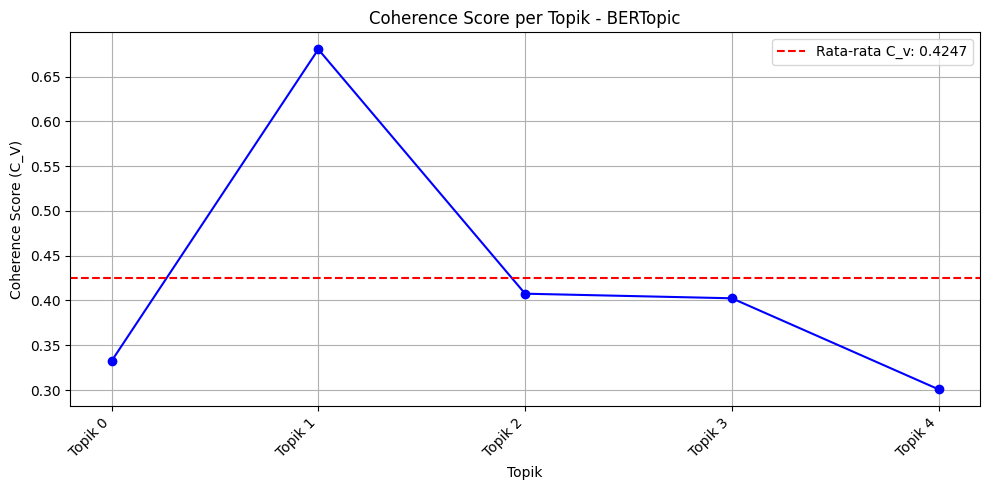

In [7]:
tokenized_docs = [doc.split() for doc in docs]
dictionary = Dictionary(tokenized_docs)

topics_words = []
topic_ids = []
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]
        topics_words.append(words)
        topic_ids.append(topic_id)

if topics_words:
    cv_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    cv_score = cv_model.get_coherence()
    cv_per_topic = cv_model.get_coherence_per_topic()

    print(f"C_v Coherence Score: {cv_score:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(
        [f"Topik {t}" for t in topic_ids],
        cv_per_topic,
        marker='o', color='b'
    )
    plt.axhline(y=cv_score, color='red', linestyle='--',
                label=f'Rata-rata C_v: {cv_score:.4f}')
    plt.xlabel('Topik')
    plt.ylabel('Coherence Score (C_V)')
    plt.title('Coherence Score per Topik - BERTopic')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('hasil_bertopic_news/coherence_score_bertopic_news.png', dpi=150)
    plt.show()
else:
    print("Tidak ada topik yang terbentuk.")

In [8]:
def topic_diversity(topic_model, topics, top_n=10):
    topics_words = []
    for topic_id in set(topics):
        if topic_id != -1:
            words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n]]
            topics_words.append(words)

    all_words = [word for topic in topics_words for word in topic]
    unique_words = set(all_words)
    diversity = len(unique_words) / len(all_words) if all_words else 0
    return diversity

td_score = topic_diversity(topic_model, topics)
print(f"Topic Diversity: {td_score:.4f}")

Topic Diversity: 0.5600


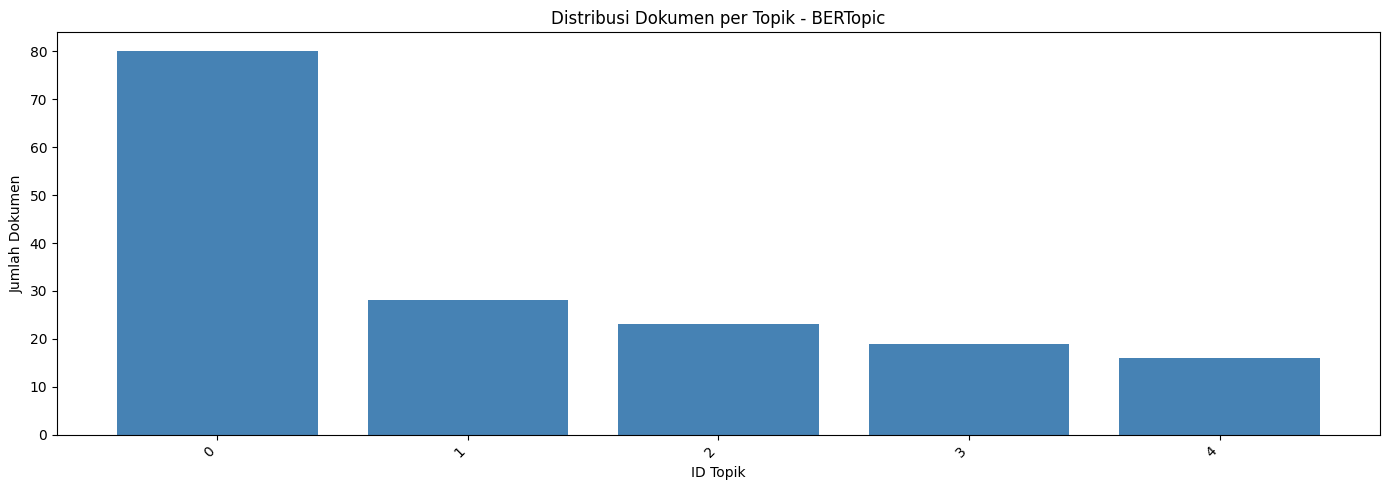

Visualisasi selesai.


In [9]:
# Topic-Word Scores
fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=10)
pio.write_html(fig_barchart, 'hasil_bertopic_news/barchart_topik_news.html')

# Intertopic Distance Map
fig_topics = topic_model.visualize_topics()
pio.write_html(fig_topics, 'hasil_bertopic_news/intertopic_distance_news.html')

# Distribusi dokumen per topik
topic_info_clean = topic_model.get_topic_info()
topic_info_clean = topic_info_clean[topic_info_clean['Topic'] != -1]

plt.figure(figsize=(14, 5))
plt.bar(
    topic_info_clean['Topic'].astype(str),
    topic_info_clean['Count'],
    color='steelblue'
)
plt.xlabel('ID Topik')
plt.ylabel('Jumlah Dokumen')
plt.title('Distribusi Dokumen per Topik - BERTopic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hasil_bertopic_news/distribusi_dokumen_per_topik_news.png', dpi=150)
plt.show()

print("Visualisasi selesai.")

In [10]:
topic_model.save(
    "hasil_bertopic_news/model/bertopic_model",
    serialization="safetensors",
    save_embedding_model=False,
    save_ctfidf=True
)

loaded_model = BERTopic.load(
    "hasil_bertopic_news/model/bertopic_model",
    embedding_model=embedding_model
)

print("Model berhasil disimpan dan diverifikasi.")

2026-06-09 22:13:01,697 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Model berhasil disimpan dan diverifikasi.
